# Data Understanding - India Real Estate Dataset

This notebook focuses only on understanding the raw India real estate dataset before any validation, cleaning, preprocessing, or modeling work.

## Objective

The goal is to understand the dataset structure, variables, data types, distributions, missing values, cardinality, and early modeling considerations.

This notebook does **not** clean data, parse raw price strings, engineer features, remove duplicates, fill missing values, or train any model.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

## Define Dataset Path

The raw dataset is referenced through a relative path so the notebook remains portable inside the project.

In [26]:
DATASET_PATH = Path("../data/raw/Real Estate Data V21.csv")
print(f"Dataset path: {DATASET_PATH}")
print(f"Path exists: {DATASET_PATH.exists()}")

Dataset path: ..\data\raw\Real Estate Data V21.csv
Path exists: True


## Load Dataset

In [27]:
df = pd.read_csv(DATASET_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


## Dataset Shape

In [28]:
rows, columns = df.shape
shape_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [rows, columns],
})
shape_summary

,Metric,Value
0,Rows,14528
1,Columns,9


## Preview Data

Looking at both the first and last few rows helps confirm the basic structure and whether the raw fields appear consistent across the file.

In [29]:
print("First 5 rows")
display(df.head())

print("Last 5 rows")
display(df.tail())

First 5 rows


,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, Chennai",₹1.99 Cr,"Kanathur Reddikuppam, Chennai",2583,"7,700.00","Best 4 BHK Apartment for modern-day lifestyle is now available for sale. No brokerage involved, Posted by Owner. Gra...",4,Yes
1,"Ramanathan Nagar, Pozhichalur,Chennai","10 BHK Independent House for sale in Pozhichalur, Chennai",₹2.25 Cr,"Ramanathan Nagar, Pozhichalur,Chennai",7000,"3,210.00",Looking for a 10 BHK Independent House for sale in Chennai? Your search ends here. Buy this 10 BHK property in Chenn...,6,Yes
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",₹1.0 Cr,"Kasthuribai Nagar, West Tambaram,Chennai",1320,"7,580.00","Property for sale in Tambaram, Chennai. This 3 BHK Apartment is located in Chennai's most promising location. This p...",3,No
3,"Naveenilaya,Chepauk, Triplicane,Chennai","7 BHK Independent House for sale in Triplicane, Chennai",₹3.33 Cr,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,"7,840.00",Entire Building for sale with 7 units of single bedroom and 2 units of double bed room with ground floor Parking wit...,5,Yes
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",₹48.0 L,"Avadi, Chennai",960,"5,000.00","Property for sale in Avadi, Chennai. This 2 BHK Apartment is located in Chennai's most promising location. This prop...",3,Yes


Last 5 rows


,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
14523,"Krishna Park Extension, Tilak Nagar,New Delhi","2 BHK Flat for sale in Tilak Nagar, New Delhi",₹40.0 L,"Krishna Park Extension, Tilak Nagar,New Delhi",1053,"3,800.00","Looking for a good 2 BHK Apartment in Tilak Nagar, Delhi? This property is in one of Delhi's most popular locations....",3,Yes
14524,"Rawta, Jaffarpur Kalan,New Delhi","1 BHK Independent House for sale in Jaffarpur Kalan, New Delhi",₹14.0 L,"Rawta, Jaffarpur Kalan,New Delhi",472,"2,970.00","1 BHK Independent House for sale in Jaffarpur Kalan, Delhi. This 1 BHK unit is available in Jaffarpur Kalan and offe...",2,Yes
14525,"Rani Garden, Geeta Colony,New Delhi","1 BHK Flat for sale in Geeta Colony, New Delhi",₹30.0 L,"Rani Garden, Geeta Colony,New Delhi",378,"7,940.00","Property for sale in Geeta Colony, Delhi. This 1 BHK Apartment is located in Delhi's most promising location. This p...",1,Yes
14526,"Lig flat rohini,Sector 16E, Sector 16 Rohini,New Delhi","3 BHK Flat for sale in Sector 16 Rohini, New Delhi",₹60.0 L,"Lig flat rohini,Sector 16E, Sector 16 Rohini,New Delhi",700,"8,570.00","Check out this 3 BHK Apartment for sale in Rohini, Delhi. This property is posted by owner and thus there is no need...",2,Yes
14527,"Sector 3B, Sector 3 Rohini,New Delhi","1 RK Independent House for sale in Sector 3 Rohini, New Delhi",₹55.0 L,"Sector 3B, Sector 3 Rohini,New Delhi",344,"15,990.00","This is an independent DDA house(in raw condition),which can be constructed upto 4 floors More About This Property L...",1,Yes


## Column Names

In [30]:
pd.DataFrame({"Column Name": df.columns})

,Column Name
0,Name
1,Property Title
2,Price
3,Location
4,Total_Area
5,Price_per_SQFT
6,Description
7,Baths
8,Balcony


## Data Types

In [31]:
df.dtypes

Name                  str
Property Title        str
Price                 str
Location              str
Total_Area          int64
Price_per_SQFT    float64
Description           str
Baths               int64
Balcony               str
dtype: object

## Dataset Information

`df.info()` gives a compact view of non-null counts and inferred data types without changing the data.

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14528 entries, 0 to 14527
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            14528 non-null  str    
 1   Property Title  14528 non-null  str    
 2   Price           14528 non-null  str    
 3   Location        14528 non-null  str    
 4   Total_Area      14528 non-null  int64  
 5   Price_per_SQFT  14528 non-null  float64
 6   Description     14528 non-null  str    
 7   Baths           14528 non-null  int64  
 8   Balcony         14528 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 1021.6 KB


## Missing Values

No pandas-recognized null values were found in the dataset.

However, semantic missing or invalid values represented as strings or unusual values may still exist. These will be investigated during the data validation milestone.

At this stage, no missing-value imputation or removal is performed.

In [33]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2),
}).sort_values(["Missing Count", "Missing Percentage"], ascending=False)
missing_summary

,Missing Count,Missing Percentage
Name,0,0.00
Property Title,0,0.00
Price,0,0.00
Location,0,0.00
Total_Area,0,0.00
Price_per_SQFT,0,0.00
Description,0,0.00
Baths,0,0.00
Balcony,0,0.00


## Duplicate Rows

Exact duplicate rows are inspected as part of the initial dataset understanding.

The dataset contains a small number of exact duplicate records. These records are not removed at this stage because duplicate rows may represent repeated listings, repeated observations, or genuine duplicate records.

The reason for the duplicates and their effect on the dataset will be investigated during the data validation milestone.

No rows are deleted or modified in this notebook.

In [34]:
duplicate_rows = int(df.duplicated().sum())
print(f"Exact duplicate rows: {duplicate_rows}")

Exact duplicate rows: 8


## Unique Values

Unique-value counts help identify high-cardinality fields, near-identifiers, and columns that may need special preprocessing later.

In [35]:
unique_values = df.nunique(dropna=True).sort_values(ascending=False).to_frame("Unique Values")
unique_values

,Unique Values
Description,14490
Name,9998
Location,7050
Property Title,6507
Price_per_SQFT,2094
Total_Area,1774
Price,891
Baths,6
Balcony,2


## Descriptive Statistics

Numerical columns are summarized with standard descriptive statistics, while text-like columns are profiled using counts, cardinality, and frequent values.

In [36]:
numeric_describe = df.describe().transpose()
numeric_describe

,count,mean,std,min,25%,50%,75%,max
Total_Area,"14,528.00","1,297.92","1,245.69",70.00,650.00,"1,000.00","1,439.00","35,000.00"
Price_per_SQFT,"14,528.00","11,719.46","49,036.07",0.00,"4,480.00","6,050.00","9,312.50","999,000.00"
Baths,"14,528.00",2.75,0.90,1.00,2.00,3.00,3.00,6.00


In [37]:
categorical_describe = df.describe(include=["object", "string"]).transpose()
categorical_describe[["count", "unique", "top", "freq"]]

,count,unique,top,freq
Name,14528,9998,Classic Apartment,42
Property Title,14528,6507,"2 BHK Flat for sale in Electronic City, Bangalore",53
Price,14528,891,₹60.0 L,407
Location,14528,7050,"Sector 12 Dwarka, New Delhi",44
Description,14528,14490,"Premier Inspira Maplewood in Sarjapur Road, Bangalore is a well-crafted township. It has a number of apartments avai...",5
Balcony,14528,2,Yes,8580


## Numerical Columns

The numerical columns are identified directly from the loaded data types instead of being assumed in advance.

In [38]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
pd.DataFrame({"Numerical Columns": numeric_columns})

,Numerical Columns
0,Total_Area
1,Price_per_SQFT
2,Baths


## Categorical and Text Columns

These columns are stored as strings and may contain identifiers, free text, raw target values, or high-cardinality categories.

In [39]:
text_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
pd.DataFrame({"Categorical/Text Columns": text_columns})

,Categorical/Text Columns
0,Name
1,Property Title
2,Price
3,Location
4,Description
5,Balcony


## Target Candidate

`Price` is the most likely target variable for a house-price prediction problem because it represents the sale value that a future model would try to estimate.

At the same time, the raw `Price` field is stored as text and includes unit-based strings such as `Cr` and `L`, so any parsing or normalization belongs in a later validation/preprocessing step rather than this notebook.

In [40]:
price_series = df["Price"].astype(str)
non_standard_price_mask = ~(price_series.str.contains("Cr", regex=False) | price_series.str.contains("L", regex=False))

price_summary = pd.DataFrame({
    "Metric": [
        "Unique raw price values",
        "Most frequent raw price",
        "Frequency of most frequent raw price",
        "Rows without Cr/L unit markers",
    ],
    "Value": [
        int(df["Price"].nunique(dropna=True)),
        df["Price"].mode().iat[0],
        int(df["Price"].value_counts().iloc[0]),
        int(non_standard_price_mask.sum()),
    ],
})

print("Sample raw Price values")
display(df["Price"].drop_duplicates().head(10).to_frame(name="Price"))

print("Top 10 most frequent raw Price values")
display(df["Price"].value_counts().head(10).to_frame(name="Count"))

print("Price field summary")
price_summary

Sample raw Price values


,Price
0,₹1.99 Cr
1,₹2.25 Cr
2,₹1.0 Cr
3,₹3.33 Cr
4,₹48.0 L
5,₹40.0 L
6,₹60.0 L
7,₹72.35 L
8,₹42.0 L
9,₹30.0 L


Top 10 most frequent raw Price values


,Count
Price,
₹60.0 L,407
₹45.0 L,375
₹65.0 L,350
₹75.0 L,350
₹35.0 L,349
₹55.0 L,346
₹70.0 L,313
₹50.0 L,308
₹40.0 L,305


Price field summary


,Metric,Value
0,Unique raw price values,891
1,Most frequent raw price,₹60.0 L
2,Frequency of most frequent raw price,407
3,Rows without Cr/L unit markers,4


## Feature Overview

The table below gives a concise first-pass interpretation of each raw column without changing the underlying data.

In [41]:
role_notes = {
    "Name": "high-cardinality text field",
    "Property Title": "text field; may contain BHK/property information",
    "Price": "candidate target; stored as text",
    "Location": "high-cardinality location field",
    "Total_Area": "numerical property-size feature",
    "Price_per_SQFT": "potentially target-derived; requires leakage validation",
    "Description": "high-cardinality free-text field",
    "Baths": "numerical bathroom-count feature",
    "Balcony": "property characteristic; representation needs validation",
}

feature_overview = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [str(df[column].dtype) for column in df.columns],
    "Unique Values": [int(df[column].nunique(dropna=True)) for column in df.columns],
    "Missing Values": [int(df[column].isna().sum()) for column in df.columns],
    "Role / Initial Interpretation": [role_notes[column] for column in df.columns],
})
feature_overview

,Column,Data Type,Unique Values,Missing Values,Role / Initial Interpretation
0,Name,str,9998,0,high-cardinality text field
1,Property Title,str,6507,0,text field; may contain BHK/property information
2,Price,str,891,0,candidate target; stored as text
3,Location,str,7050,0,high-cardinality location field
4,Total_Area,int64,1774,0,numerical property-size feature
5,Price_per_SQFT,float64,2094,0,potentially target-derived; requires leakage validation
6,Description,str,14490,0,high-cardinality free-text field
7,Baths,int64,6,0,numerical bathroom-count feature
8,Balcony,str,2,0,property characteristic; representation needs validation


## Special Columns Requiring Investigation

Some raw fields are especially important because they may contain embedded structure, unusually high cardinality, or relationships that need formal checking in the next notebook.

In [42]:
special_columns = pd.DataFrame([
    {
        "Column": "Price",
        "Current Observation": "Stored as raw text with unit markers such as Cr and L, plus a few non-standard entries",
        "Why it matters later": "Needs unit standardization before it can be modeled or compared numerically",
    },
    {
        "Column": "Total_Area",
        "Current Observation": "Already numeric, but values span a very wide range",
        "Why it matters later": "Needs validation for unit consistency, outliers, and possible area-definition differences",
    },
    {
        "Column": "Price_per_SQFT",
        "Current Observation": "Numeric field with extreme values and a plausible relationship to price and area",
        "Why it matters later": "Must be checked for derivation and leakage risk before any model uses it",
    },
    {
        "Column": "Property Title",
        "Current Observation": "Contains BHK counts, property type words, and locality text in one string",
        "Why it matters later": "May support feature extraction after validation, but should stay raw here",
    },
    {
        "Column": "Location",
        "Current Observation": "Free-form location text with very high cardinality",
        "Why it matters later": "Likely needs normalization, deduplication, or geographic parsing",
    },
    {
        "Column": "Description",
        "Current Observation": "Long unstructured listing description with almost one unique value per row",
        "Why it matters later": "Could hold useful information, but requires careful text handling and duplication checks",
    },
    {
        "Column": "Baths",
        "Current Observation": "Discrete numeric count with a small set of possible values",
        "Why it matters later": "Should be checked for consistency with title and description-derived details",
    },
    {
        "Column": "Balcony",
        "Current Observation": "Binary-looking Yes/No text field",
        "Why it matters later": "Needs confirmation on whether it indicates presence only or actual balcony count",
    },
])
special_columns

,Column,Current Observation,Why it matters later
0,Price,"Stored as raw text with unit markers such as Cr and L, plus a few non-standard entries",Needs unit standardization before it can be modeled or compared numerically
1,Total_Area,"Already numeric, but values span a very wide range","Needs validation for unit consistency, outliers, and possible area-definition differences"
2,Price_per_SQFT,Numeric field with extreme values and a plausible relationship to price and area,Must be checked for derivation and leakage risk before any model uses it
3,Property Title,"Contains BHK counts, property type words, and locality text in one string","May support feature extraction after validation, but should stay raw here"
4,Location,Free-form location text with very high cardinality,"Likely needs normalization, deduplication, or geographic parsing"
5,Description,Long unstructured listing description with almost one unique value per row,"Could hold useful information, but requires careful text handling and duplication checks"
6,Baths,Discrete numeric count with a small set of possible values,Should be checked for consistency with title and description-derived details
7,Balcony,Binary-looking Yes/No text field,Needs confirmation on whether it indicates presence only or actual balcony count


## Potential Target Leakage: `Price_per_SQFT`

`Price_per_SQFT` requires special attention because it may be mathematically derived from the target variable `Price` and `Total_Area`.

A possible relationship is:

`Price_per_SQFT ≈ Price / Total_Area`

If this relationship is confirmed, using `Price_per_SQFT` as an input feature to predict `Price` would introduce target leakage because the feature would contain information derived from the target itself.

Therefore:

- `Price_per_SQFT` is **not considered a model feature at this stage**.
- The raw column will **not be modified or deleted**.
- The mathematical relationship between `Price`, `Total_Area`, and `Price_per_SQFT` will be explicitly investigated during the data validation milestone.
- A final decision about whether this column can be used for modeling will only be made after validation.

This is an initial data-understanding observation, not a final feature-selection decision.

## High-Cardinality Features

High-cardinality columns can be informative, but they usually need careful handling because they create sparse categories, duplicate-looking variants, and a higher risk of overfitting if encoded naively.

In [43]:
text_cardinality = pd.DataFrame({
    "Unique Values": df[text_columns].nunique(dropna=True),
    "Unique Ratio": (df[text_columns].nunique(dropna=True) / len(df)).round(4),
}).sort_values("Unique Values", ascending=False)

high_cardinality_features = text_cardinality[text_cardinality["Unique Values"] >= 100]
high_cardinality_feature_columns = high_cardinality_features.drop(index="Price", errors="ignore").index.tolist()
high_cardinality_features

,Unique Values,Unique Ratio
Description,14490,1.00
Name,9998,0.69
Location,7050,0.49
Property Title,6507,0.45
Price,891,0.06


The results above show that `Location`, `Name`, `Property Title`, and especially `Description` are high-cardinality text fields. `Price` also has many unique raw values, but it is treated as the target candidate rather than as a predictor feature.

## Initial Distribution Inspection

The plots below provide a quick view of key numeric variables. For readability only, the `Total_Area` and `Price_per_SQFT` histograms are displayed up to their 99th percentile, but the original `df` is not modified.

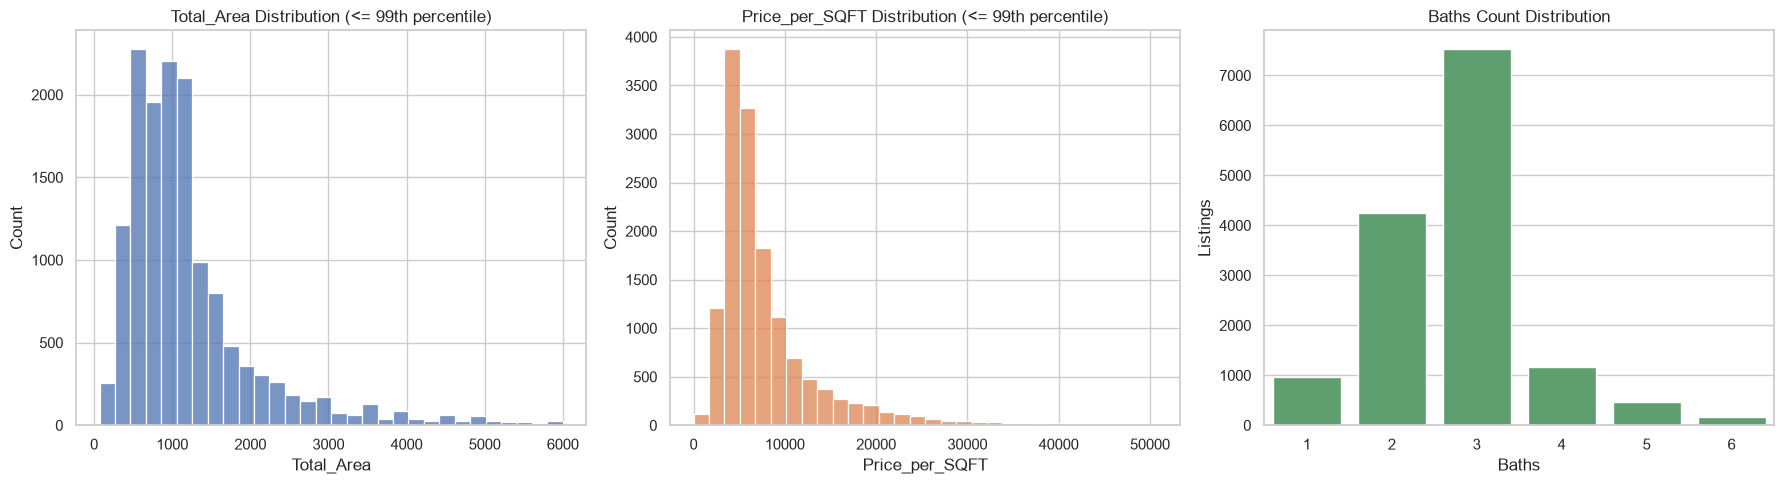

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

total_area_cap = df["Total_Area"].quantile(0.99)
price_per_sqft_cap = df["Price_per_SQFT"].quantile(0.99)

sns.histplot(
    df.loc[df["Total_Area"] <= total_area_cap, "Total_Area"],
    bins=30,
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_title("Total_Area Distribution (<= 99th percentile)")
axes[0].set_xlabel("Total_Area")

sns.histplot(
    df.loc[df["Price_per_SQFT"] <= price_per_sqft_cap, "Price_per_SQFT"],
    bins=30,
    ax=axes[1],
    color="#DD8452",
)
axes[1].set_title("Price_per_SQFT Distribution (<= 99th percentile)")
axes[1].set_xlabel("Price_per_SQFT")

sns.countplot(
    data=df,
    x="Baths",
    order=sorted(df["Baths"].dropna().unique()),
    ax=axes[2],
    color="#55A868",
)
axes[2].set_title("Baths Count Distribution")
axes[2].set_xlabel("Baths")
axes[2].set_ylabel("Listings")

plt.tight_layout()
plt.show()

## Initial Categorical Inspection

The goal here is to inspect a few useful category distributions without over-plotting high-cardinality fields. `Location` is summarized with its most frequent values, while `Balcony` is simple enough for a direct count plot.

In [45]:
balcony_counts = df["Balcony"].value_counts()
top_locations = df["Location"].value_counts().head(10)
top_names = df["Name"].value_counts().head(10)
description_uniqueness = pd.DataFrame({
    "Metric": ["Unique descriptions", "Repeated descriptions", "Unique ratio"],
    "Value": [
        int(df["Description"].nunique(dropna=True)),
        int(len(df) - df["Description"].nunique(dropna=True)),
        round(df["Description"].nunique(dropna=True) / len(df), 4),
    ],
})

print("Balcony value counts")
display(balcony_counts.to_frame(name="Count"))

print("Top 10 locations by frequency")
display(top_locations.to_frame(name="Count"))

print("Top 10 names by frequency")
display(top_names.to_frame(name="Count"))

print("Description cardinality check")
description_uniqueness

Balcony value counts


,Count
Balcony,
Yes,8580
No,5948


Top 10 locations by frequency


,Count
Location,
"Sector 12 Dwarka, New Delhi",44
"Wagholi, Pune",39
"Bannerughatta, Bangalore",35
"Horamavu Agara, Horamavu,Bangalore",32
"Chakan, Pune",32
"Veer Sandra, Electronic City,Bangalore",31
"Mattanahalli, Bangalore",31
"Yelahanka, Bangalore",30
"Veer Sandra, Electronic City Phase II,Bangalore",29


Top 10 names by frequency


,Count
Name,
Classic Apartment,42
DDA Flats,34
"Veer Sandra, Electronic City,Bangalore",30
"Bannerughatta, Bangalore",25
"Dharampura, Najafgarh,New Delhi",20
"Horamavu Agara, Horamavu,Bangalore",19
"Thotada Guddadhalli Village, Bangalore",18
"Hindustan Antibiotics Colony, Pimpri,Pune",18
"Srinivasa Nagar, Banashankari,Bangalore",17


Description cardinality check


,Metric,Value
0,Unique descriptions,"14,490.00"
1,Repeated descriptions,38.00
2,Unique ratio,1.00


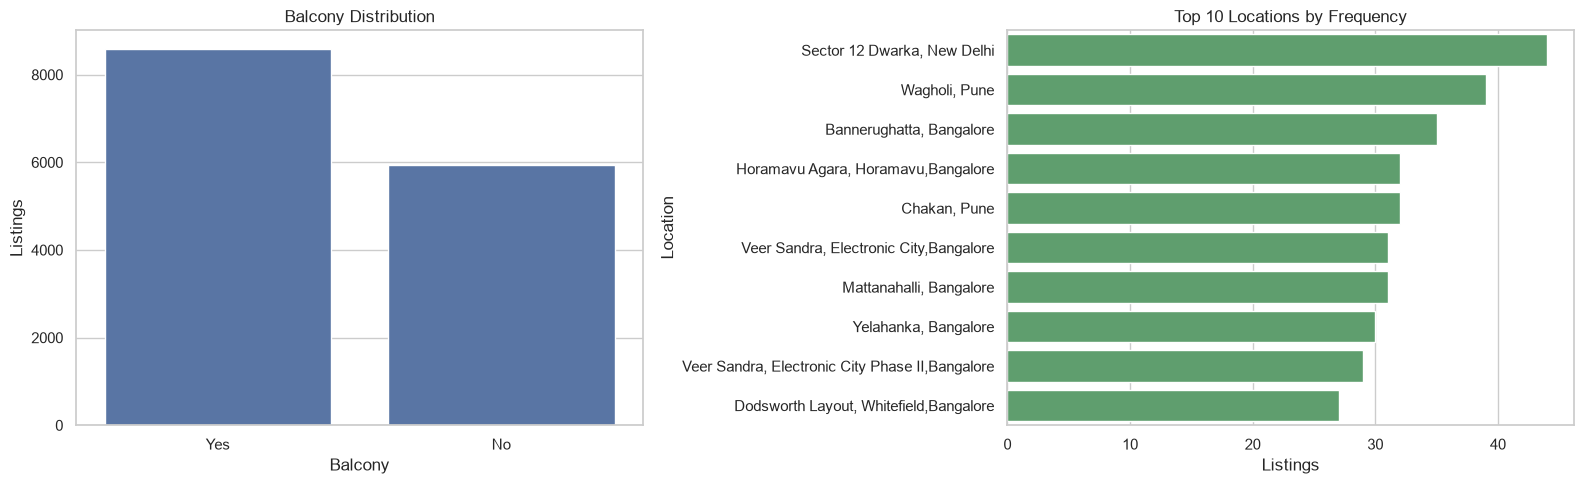

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=balcony_counts.index, y=balcony_counts.values, ax=axes[0], color="#4C72B0")
axes[0].set_title("Balcony Distribution")
axes[0].set_xlabel("Balcony")
axes[0].set_ylabel("Listings")

sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[1], color="#55A868")
axes[1].set_title("Top 10 Locations by Frequency")
axes[1].set_xlabel("Listings")
axes[1].set_ylabel("Location")

plt.tight_layout()
plt.show()

## Final Conclusions

- The dataset contains **14,528 property listings and 9 columns**.
- `Price` is identified as the **target variable** for the prediction task.
- `Total_Area` and `Baths` are potential numerical features that may help predict property price.
- `Location`, `Property Title`, and `Description` contain additional property information that may be useful after further investigation.
- `Price_per_SQFT` may be calculated from `Price` and `Total_Area`, so it must be carefully checked for **target leakage** before being considered as a feature.
- No standard missing values were found in the dataset.
- Duplicate records and high-cardinality columns were identified and will be investigated in later stages.
- The raw dataset was **not modified** during data understanding.

### Next Step

The next stage is **Data Validation**, where we will verify data quality, investigate duplicates and unusual values, and formally test whether `Price_per_SQFT` contains target leakage.